<a href="https://colab.research.google.com/github/vatsdivyansh/housing-price-prediction/blob/main/housing_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Process :
EDA-> preprocessing -> baseline model -> model selection(CV) -> tuning(GridSearchCV)->final evaluation ->inference


In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , KFold , cross_validate , GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.ensemble import RandomForestRegressor , HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error ,
    root_mean_squared_error ,
    r2_score
)

In [3]:
#congiguration details for the Notebook :
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x: 3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10 ,
    "axes.labelsize": 9 ,
    "xtick.labelsize": 8 ,
    "ytick.labelsize" : 8
})

RANDOM_STATE = 42
CSV_PATH = "housing.csv"
TARGET_COL = "median_house_value"

In [4]:
df= pd.read_csv(CSV_PATH)


In [5]:
print("DataFrame shape" , df.shape)

DataFrame shape (20640, 10)


In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230000,37.880000,41.000000,880.000000,129.000000,322.000000,126.000000,8.325200,452600.000000,NEAR BAY
1,-122.220000,37.860000,21.000000,7099.000000,1106.000000,2401.000000,1138.000000,8.301400,358500.000000,NEAR BAY
2,-122.240000,37.850000,52.000000,1467.000000,190.000000,496.000000,177.000000,7.257400,352100.000000,NEAR BAY
3,-122.250000,37.850000,52.000000,1274.000000,235.000000,558.000000,219.000000,5.643100,341300.000000,NEAR BAY
4,-122.250000,37.850000,52.000000,1627.000000,280.000000,565.000000,259.000000,3.846200,342200.000000,NEAR BAY


In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target columns:" , TARGET_COL)
print("Numerical columns:" , num_cols)
print("Categorical columns:" , cat_cols)

Target columns: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [10]:
#missing values analysis
print(df.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [11]:
#checking presence of encoded missing values

for col in df.columns:
  print(df[col].value_counts().head(20))

longitude
-118.310000    162
-118.300000    160
-118.290000    148
-118.270000    144
-118.320000    142
-118.280000    141
-118.350000    140
-118.360000    138
-118.190000    135
-118.250000    128
-118.370000    128
-118.200000    126
-118.140000    125
-118.260000    121
-118.130000    121
-118.180000    120
-118.340000    119
-118.210000    118
-118.150000    116
-118.120000    112
Name: count, dtype: int64
latitude
34.060000    244
34.050000    236
34.080000    234
34.070000    231
34.040000    221
34.090000    212
34.020000    208
34.100000    203
34.030000    193
33.930000    181
33.940000    175
33.970000    172
33.990000    168
33.880000    164
33.980000    162
34.110000    162
34.160000    159
34.120000    158
34.150000    157
34.010000    156
Name: count, dtype: int64
housing_median_age
52.000000    1273
36.000000     862
35.000000     824
16.000000     771
17.000000     698
34.000000     689
26.000000     619
33.000000     615
18.000000     570
25.000000     566
32.000000 

In [12]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:" , num_duplicates)

Number of duplicate rows: 0


In [13]:
#descriptive stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [14]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000000,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
latitude,20640.000000,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
housing_median_age,20640.000000,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
total_rooms,20640.000000,2635.763081,2181.615252,2.000000,1447.750000,2127.000000,3148.000000,39320.000000
total_bedrooms,20433.000000,537.870553,421.385070,1.000000,296.000000,435.000000,647.000000,6445.000000
population,20640.000000,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
households,20640.000000,499.539680,382.329753,1.000000,280.000000,409.000000,605.000000,6082.000000
median_income,20640.000000,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
median_house_value,20640.000000,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000


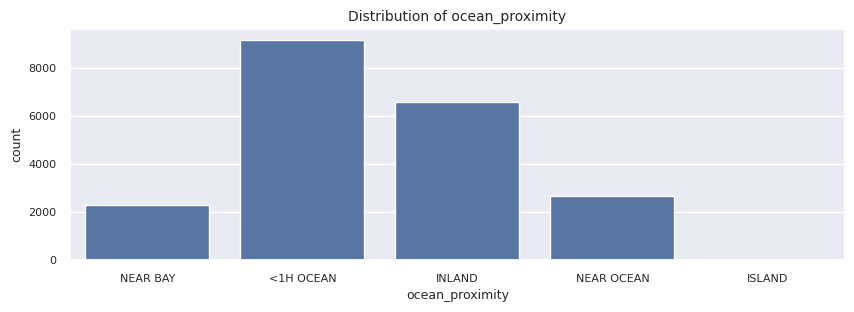

In [15]:
#countplot for categorical columns
for col in cat_cols:
  plt.figure(figsize=(10,3))
  sns.countplot(x=col,data=df)
  plt.title(f"Distribution of {col}")
  plt.show()

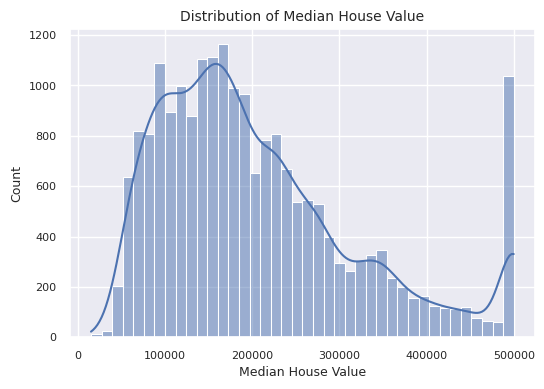

In [16]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df["median_house_value"],bins=40,kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.show()


In [17]:
for col in cat_cols :
  print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [18]:
df[TARGET_COL].value_counts()

,count
median_house_value,
500001.000000,965
137500.000000,122
162500.000000,117
112500.000000,103
187500.000000,93
...,...
34200.000000,1
46200.000000,1
352000.000000,1


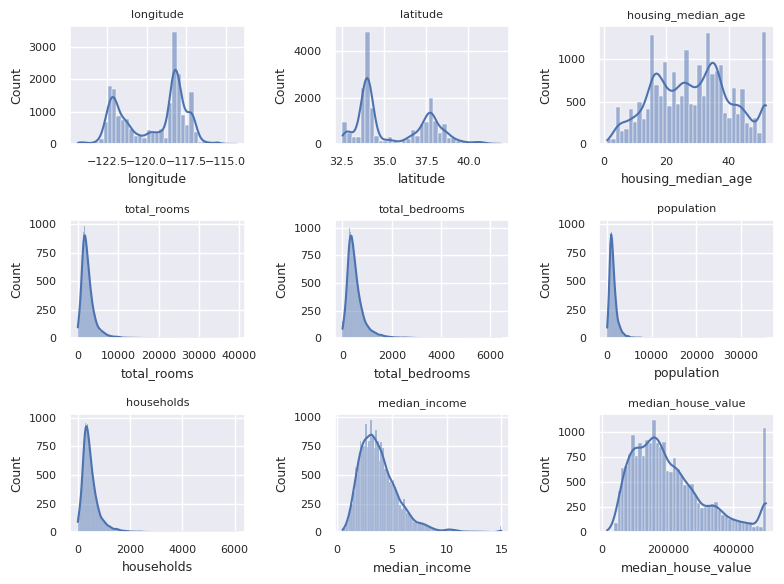

In [19]:
# histogram plot- distribution
fig , axes = plt.subplots(3,3,figsize=(8,6))
axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.histplot(df[col],kde=True,ax=axes[i])
  axes[i].set_title(col,fontsize=8)

plt.tight_layout()
plt.show()



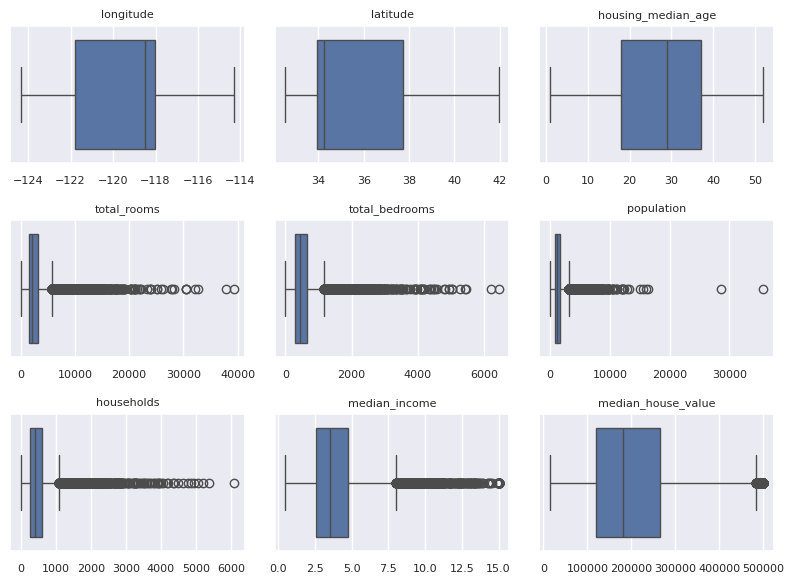

In [20]:
#outliers ananlysis - boxplot
fig,axes = plt.subplots(3,3,figsize=(8,6))
axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.boxplot(x=df[col],ax=axes[i])
  axes[i].set_title(col,fontsize=8)
  axes[i].set_xlabel("")
plt.tight_layout()
plt.show()


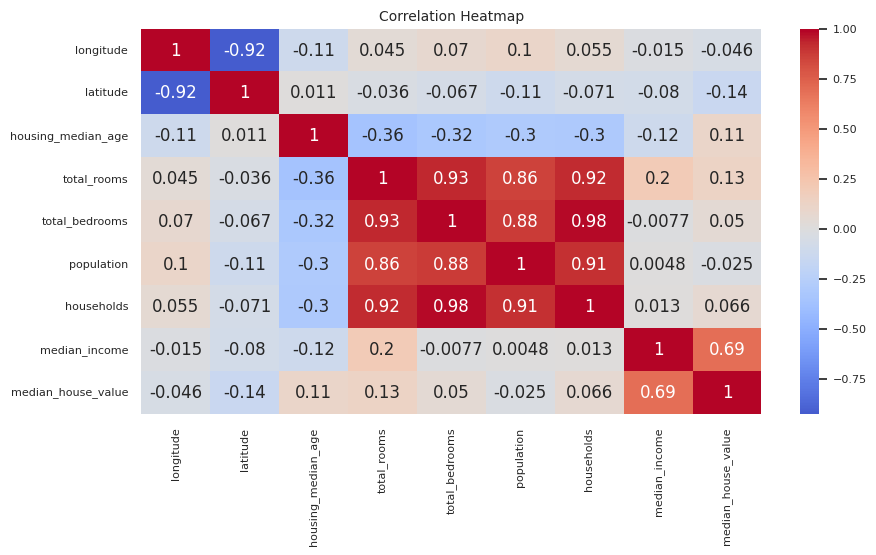

In [21]:
#identify presence of highly correlated columns and feature relationships
plt.figure(figsize=(10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot = True ,
    cmap = "coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
#Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print(corr_with_target)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


🔍 Key Insights from EDA
Dataset has numeric + one categorical feature (ocean_proximity)
Only total_bedrooms has missing values
Target (median_house_value) is right-skewed and capped
Several features show strong skew and outliers
median_income is the strongest predictor
High multicollinearity among room and population features
⚙️ Preprocessing & Evaluation Plan
Median imputation for missing values
One-hot encoding for categorical feature
Feature scaling for linear models
Use pipelines to avoid data leakage
Baseline model → CV model selection → hyperparameter tuning
Primary metric: RMSE, secondary: MAE and R²
Final evaluation only on test set



DATA PREPROCESSING
⚙️ Preprocessing & Evaluation Plan
Median imputation for missing values
One-hot encoding for categorical feature
Feature scaling for linear models
Use pipelines to avoid data leakage
Baseline model → CV model selection → hyperparameter tuning
Primary metric: RMSE, secondary: MAE and R²
Final evaluation only on test set

DATA PREPROCESSING

In [23]:
#separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [24]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230000,37.880000,41.000000,880.000000,129.000000,322.000000,126.000000,8.325200,NEAR BAY
1,-122.220000,37.860000,21.000000,7099.000000,1106.000000,2401.000000,1138.000000,8.301400,NEAR BAY
2,-122.240000,37.850000,52.000000,1467.000000,190.000000,496.000000,177.000000,7.257400,NEAR BAY
3,-122.250000,37.850000,52.000000,1274.000000,235.000000,558.000000,219.000000,5.643100,NEAR BAY
4,-122.250000,37.850000,52.000000,1627.000000,280.000000,565.000000,259.000000,3.846200,NEAR BAY


In [25]:
y.head()

,median_house_value
0,452600.000000
1,358500.000000
2,352100.000000
3,341300.000000
4,342200.000000


In [26]:
#train-test split
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2 , random_state = RANDOM_STATE)

In [27]:
X_train.shape

(16512, 9)

In [28]:
X_test.shape

(4128, 9)

Preprocessing Pipeline

In [29]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [30]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [31]:
categorical_features

['ocean_proximity']

In [32]:
#numerical features -preprocessing steps
numerical_transformer = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)

In [33]:
# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [34]:
#preprocessing pipeline
preprocess = ColumnTransformer(
    transformers = [
        ("num",numerical_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)

BASELINE MODEL -- No CV , No tuning , Just Linear Regression

In [35]:
baseline_pipe = Pipeline(
    steps = [
        ("preprocess",preprocess),
        ("model",LinearRegression())
    ]
)


In [36]:
#preprocess the data and train the baseline model
baseline_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

EVALUATION OF BAELINE MODEL

In [37]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [38]:
y_train[:5]

,median_house_value
14196,103000.000000
8267,382100.000000
17445,172600.000000
14265,93400.000000
2271,96500.000000


In [39]:
train_baseline_rmse = root_mean_squared_error(y_train,train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train,train_baseline_pred)
train_baseline_r2 = r2_score(y_train,train_baseline_pred)

In [40]:
# baseline model train-metrics
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2: {train_baseline_r2: .3f}")

RMSE: 68433.937
MAE: 49594.842
R2:  0.650


In [41]:
test_baseline_rmse = root_mean_squared_error(y_test,test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2 = r2_score(y_test,test_baseline_pred)

In [42]:
#baseline model test-metrics
print(f"RMSE: {test_baseline_rmse:.2f}")
print(f"MAE: {test_baseline_mae:.2f}")
print(f"R2: {test_baseline_r2: .3f}")


RMSE: 70059.19
MAE: 50670.49
R2:  0.625


Model Selection and optimization

In [43]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(random_state=42),
    "HistGB": HistGradientBoostingRegressor()
}

In [44]:
k=5
cv = KFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)

In [45]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":"neg_mean_absolute_error",
    "r2":"r2"
}


In [46]:
rows = []
for name,model in models.items():
  print(name,model)


LinearRegression LinearRegression()
Ridge Ridge(random_state=42)
Lasso Lasso(max_iter=10000, random_state=42)
RandomForest RandomForestRegressor(random_state=42)
HistGB HistGradientBoostingRegressor()


In [47]:
for name,model in models.items():
  pipe = Pipeline(
      steps=[
          ("preprocess",preprocess),
          ("model",model)
      ]
  )
  scores = cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
  rows.append(
      {
          "model": name ,
          "cv_rmse":-scores["test_rmse"].mean(),
          "cv_mae":-scores["test_mae"].mean(),
          "cv_r2":-scores["test_r2"].mean(),

      }
  )

#sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV MODEL COMPARISON ===")
print(cv_results)



=== CV MODEL COMPARISON ===
              model       cv_rmse        cv_mae     cv_r2
4            HistGB  48369.484421  32472.872242 -0.824938
3      RandomForest  49445.286035  32328.532731 -0.817076
1             Ridge  68595.617399  49664.330927 -0.647760
2             Lasso  68603.233277  49667.262611 -0.647685
0  LinearRegression  68604.162955  49667.159067 -0.647676


In [48]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,48369.484421,32472.872242,-0.824938
3,RandomForest,49445.286035,32328.532731,-0.817076
1,Ridge,68595.617399,49664.330927,-0.647760
2,Lasso,68603.233277,49667.262611,-0.647685
0,LinearRegression,68604.162955,49667.159067,-0.647676


In [49]:
scores # these scores are for HistGB

{'fit_time': array([0.75115848, 0.49171233, 0.44483805, 0.45920372, 0.45221567]),
 'score_time': array([0.06563067, 0.05448341, 0.04975104, 0.0531342 , 0.04825211]),
 'test_rmse': array([-49592.34521767, -48288.99713499, -47466.57358132, -49299.55153794,
        -47199.95463082]),
 'test_mae': array([-33122.38739314, -32523.77056332, -32068.64463607, -32557.60968838,
        -32091.94892701]),
 'test_r2': array([0.82178099, 0.82445395, 0.83105158, 0.81958614, 0.82781894])}

In [50]:
rows

[{'model': 'LinearRegression',
  'cv_rmse': np.float64(68604.16295529754),
  'cv_mae': np.float64(49667.15906724985),
  'cv_r2': np.float64(-0.6476757451183028)},
 {'model': 'Ridge',
  'cv_rmse': np.float64(68595.61739914853),
  'cv_mae': np.float64(49664.330927177056),
  'cv_r2': np.float64(-0.6477600560394983)},
 {'model': 'Lasso',
  'cv_rmse': np.float64(68603.2332772403),
  'cv_mae': np.float64(49667.26261132317),
  'cv_r2': np.float64(-0.6476847875205972)},
 {'model': 'RandomForest',
  'cv_rmse': np.float64(49445.28603543163),
  'cv_mae': np.float64(32328.532730978925),
  'cv_r2': np.float64(-0.8170755514674996)},
 {'model': 'HistGB',
  'cv_rmse': np.float64(48369.48442054603),
  'cv_mae': np.float64(32472.872241584286),
  'cv_r2': np.float64(-0.8249383212497088)}]

f1 ,f2,f3,f4,f5 --> folds
1st Iteration --> f5 will be our test data and remaining will be train data
2nd iteration --> f4 will be our test data and remaining will be our train data
and so on..

In [51]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,48369.484421,32472.872242,-0.824938
3,RandomForest,49445.286035,32328.532731,-0.817076
1,Ridge,68595.617399,49664.330927,-0.647760
2,Lasso,68603.233277,49667.262611,-0.647685
0,LinearRegression,68604.162955,49667.159067,-0.647676


In [52]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]
best_row

,4
model,HistGB
cv_rmse,48369.484421
cv_mae,32472.872242
cv_r2,-0.824938


In [53]:
best_model_name = best_row["model"]
best_rmse =  best_row["cv_rmse"]

print(f"Best model: {best_model_name}")
print(f"Best CV RMSE: {best_rmse : .2f}")

Best model: HistGB
Best CV RMSE:  48369.48


BEST MODEL : HistGradientBoostingRegressor

HYPERPARAMETER TUNING

In [54]:
hgb_pipe = Pipeline(
    steps = [
        ("preprocess",preprocess),
        ("model",HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)


In [55]:
#hyperparameter combination
param_grid = {
    "model__learning_rate": [0.03,0.05,0.1] ,
    "model__max_depth": [None,3,6] ,
    "model__max_leaf_nodes": [15,31,63] ,
    "model__min_samples_leaf": [20,50,100],
    "model__l2_regularization": [0.0,0.1,1.0]
}


In [56]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,
    verbose=1 ,
    refit=True
)

In [57]:
#perform grid search
grid.fit(X_train,y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [58]:
print("Best CV RMSE" , -grid.best_score_)
print("Best Params" , grid.best_params_)

Best CV RMSE 47408.38131673431
Best Params {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


classification - accuracy_score -highest

regression -error -lowest - best model
why we used neg_root_mean_squared_error --> coz GridSearchCV -- the largest value is better , but we want error to be min. thats why we used negative , whichever has lowest error value will be returned actually

RETRAINING WITH BEST PARAMS

In [59]:
hgb_best = Pipeline(
    steps = [

        ("preprocess",preprocess),
        ("model",HistGradientBoostingRegressor(
            l2_regularization = 0.1,
            learning_rate = 0.1,
            max_depth = None,
            max_leaf_nodes = 63,
            min_samples_leaf = 20
        ))
    ]
)

In [60]:
grid.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63,
                                               random_state=42))])

In [61]:
# train best model on entire training data ,can also be done with refit=True in grid Search

hgb_best.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

FINAL EVALUATION

In [62]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train,train_final_pred)
train_final_mae = mean_absolute_error(y_train,train_final_pred)
train_final_r2 = r2_score(y_train,train_final_pred)

# final model (tuned HGB) Train Performance on training data
print(f"RMSE: {train_final_rmse: .3f}")
print(f"MAE: {train_final_mae: .3f}")
print(f"R2: {train_final_r2: .3f}")

RMSE:  35754.660
MAE:  24439.920
R2:  0.904


In [63]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test,test_final_pred)
test_final_mae = mean_absolute_error(y_test,test_final_pred)
test_final_r2 = r2_score(y_test,test_final_pred)

# final model (tuned HGB) Train Performance on test data
print(f"RMSE: {test_final_rmse: .3f}")
print(f"MAE: {test_final_mae: .3f}")
print(f"R2: {test_final_r2: .3f}")

RMSE:  46042.190
MAE:  30664.217
R2:  0.838


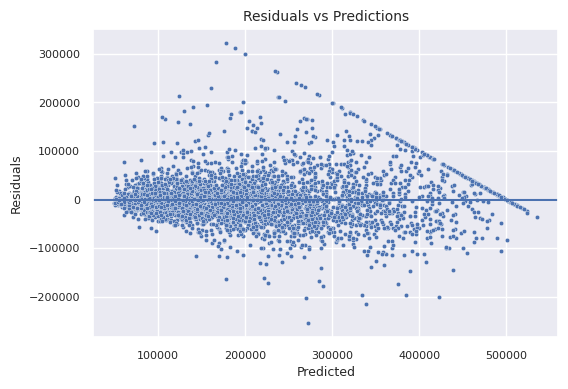

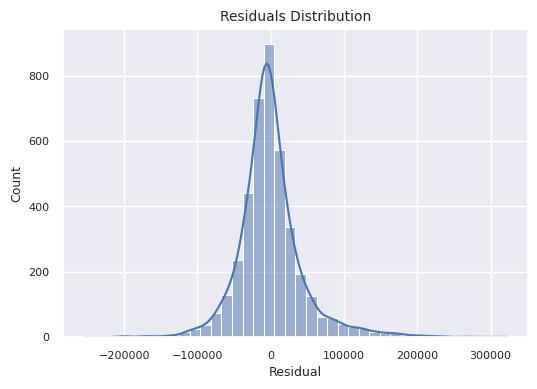

In [64]:
#residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=test_final_pred,y=residuals,s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(residuals,kde=True,bins=40)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [69]:
def predict_house_price(
    model ,
    longitude: float ,
    latitude: float ,
    housing_median_age: float ,
    total_rooms: float ,
    households: float ,
    total_bedrooms: float ,
    population: float ,
    median_income: float ,
    ocean_proximity: str ) -> float:
        """Predict median_house_value for one new house.
           total bedrooms can be np.nan (pipeline will impute)
        """

        new_row = pd.DataFrame([{
            "longitude":longitude ,
            "latitude": latitude ,
            "housing_median_age": housing_median_age ,
            "total_rooms": total_rooms ,
            "total_bedrooms": total_bedrooms ,
            "population": population ,
            "households": households ,
            "median_income": median_income ,
            "ocean_proximity": ocean_proximity
        }])
        return float(model.predict(new_row)[0])











In [70]:
example_pred = predict_house_price(
    model = hgb_best,
    longitude=-122.230,
    latitude = 37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)
print("\nExample prediction:" , round(example_pred,2))


Example prediction: 449100.28
